In [27]:
import pandas as pd
print("pandas")

pandas


In [28]:
import pandas as pd

df = pd.read_csv("../data/sample_emails.csv")
df.head()

,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        8 non-null      int64 
 1   sender    8 non-null      object
 2   subject   8 non-null      object
 3   body      8 non-null      object
 4   priority  8 non-null      object
 5   label     8 non-null      object
dtypes: int64(1), object(5)
memory usage: 516.0+ bytes


In [30]:
df.describe(include="all")

,id,sender,subject,body,priority,label
count,8.00000,8,8,8,8,8
unique,NaN,8,8,8,3,7
top,NaN,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,work
freq,NaN,1,1,1,4,2
mean,4.50000,NaN,NaN,NaN,NaN,NaN
std,2.44949,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN
25%,2.75000,NaN,NaN,NaN,NaN,NaN
50%,4.50000,NaN,NaN,NaN,NaN,NaN
75%,6.25000,NaN,NaN,NaN,NaN,NaN


In [31]:
df["label"].value_counts()

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [32]:
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

In [34]:
df['subject'] = df['subject'].str.strip().str.lower()
df['body'] = df['body'].str.strip().str.lower()

In [35]:
#Create combined text column
df['text'] = df['subject'] + ' ' + df['body']
df[['text']]

,text
0,"offer letter - please sign dear candidate, con..."
1,big billion sale is live flat 70% off on elect...
2,unusual login attempt we detected a login atte...
3,"weekly tech newsletter in this week's edition,..."
4,"coffee this weekend? hey, long time no see! ar..."
5,"you won $1,000,000!!! click here to claim your..."
6,project update required please share the statu...
7,reminder: complete mandatory training your man...


In [36]:
# show all high priority emails
high_priority = df[df['priority'] == 'high']
high_priority

,id,sender,subject,body,priority,label,text
0,1,hr@company.com,offer letter - please sign,"dear candidate, congratulations! please sign a...",high,important,"offer letter - please sign dear candidate, con..."
2,3,alerts@mybank.com,unusual login attempt,we detected a login attempt to your account fr...,high,security,unusual login attempt we detected a login atte...
5,6,spam@strange-domain.ru,"you won $1,000,000!!!",click here to claim your lottery now. do not s...,high,spam,"you won $1,000,000!!! click here to claim your..."
6,7,manager@company.com,project update required,please share the status update of your project...,high,work,project update required please share the statu...


In [39]:
# security-related emails
security_emails = df[df['text'].str.contains('login|password|security', case=False, na=False)]
security_emails

,id,sender,subject,body,priority,label,text
2,3,alerts@mybank.com,unusual login attempt,we detected a login attempt to your account fr...,high,security,unusual login attempt we detected a login atte...
7,8,training@lms.com,reminder: complete mandatory training,your mandatory security awareness training is ...,medium,work,reminder: complete mandatory training your man...


In [41]:
# promotional/sale emails
promo_emails = df[df['text'].str.contains('sale|discount', case=False, na=False)]
promo_emails

,id,sender,subject,body,priority,label,text
1,2,noreply@shopping.com,big billion sale is live,flat 70% off on electronics. limited period of...,low,promotion,big billion sale is live flat 70% off on elect...


In [44]:
df["priority"].value_counts()

priority
high      4
low       2
medium    2
Name: count, dtype: int64

In [43]:
df.shape

(8, 7)

In [45]:
df.isnull().sum()

id          0
sender      0
subject     0
body        0
priority    0
label       0
text        0
dtype: int64

In [46]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'label', 'text'], dtype='object')

In [52]:
df['clean_text']=df['body'].str.lower().str.replace('[^a-zA-Z]', ' ', regex=True)
df[['body', 'clean_text']].head()

,body,clean_text
0,"dear candidate, congratulations! please sign a...",dear candidate congratulations please sign a...
1,flat 70% off on electronics. limited period of...,flat off on electronics limited period of...
2,we detected a login attempt to your account fr...,we detected a login attempt to your account fr...
3,"in this week's edition, learn about ai agents,...",in this week s edition learn about ai agents ...
4,"hey, long time no see! are you free this weeke...",hey long time no see are you free this weeke...


In [55]:
from collections import Counter
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)
word_freq.most_common(8)

[('your', 6),
 ('this', 4),
 ('please', 3),
 ('and', 2),
 ('offer', 2),
 ('today', 2),
 ('now', 2),
 ('a', 2)]

In [90]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [word for word in all_words if word not in stop_words]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Isha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [120]:
#Stemming
from nltk.stem import PorterStemmer

# Initialize stemmer
stemmer = PorterStemmer()

In [121]:
# Function to stem a single email's text
def stem_sentence(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

In [122]:
df['stemmed_text'] = df['clean_text'].apply(stem_sentence)
df[['body', 'clean_text', 'stemmed_text']].head()

,body,clean_text,stemmed_text
0,"dear candidate, congratulations! please sign a...",offer letter please sign dear candidate congr...,offer letter pleas sign dear candid congratul ...
1,flat 70% off on electronics. limited period of...,big billion sale is live flat 70 off on electr...,big billion sale is live flat 70 off on electr...
2,we detected a login attempt to your account fr...,unusual login attempt we detected a login atte...,unusu login attempt we detect a login attempt ...
3,"in this week's edition, learn about ai agents,...",weekly tech newsletter in this weeks edition l...,weekli tech newslett in thi week edit learn ab...
4,"hey, long time no see! are you free this weeke...",coffee this weekend hey long time no see are y...,coffe thi weekend hey long time no see are you...


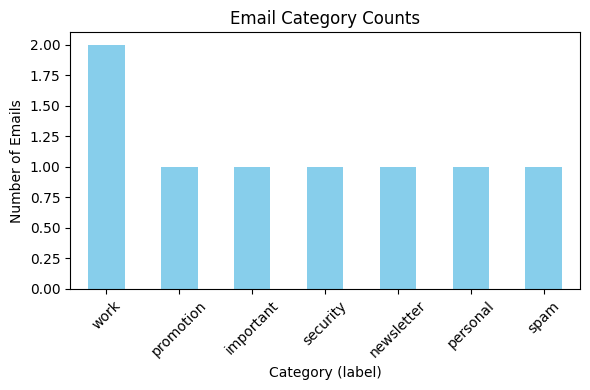

In [123]:
# Visualize category counts using a bar chart
import matplotlib.pyplot as plt

# Category counts (labels)
label_counts = df['label'].value_counts()

plt.figure(figsize=(6,4))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Email Category Counts')
plt.xlabel('Category (label)')
plt.ylabel('Number of Emails')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


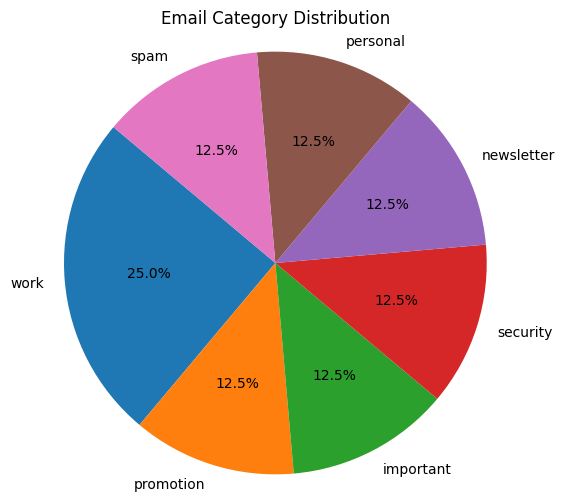

In [ ]:
# Visualize category distribution using a pie chart
import matplotlib.pyplot as plt

# Category (label) counts
label_counts = df['label'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Email Category Distribution')
plt.axis('equal')  
plt.show()


In [125]:
# Extract top 5 keywords per category
from collections import Counter

def top_keywords_for_category(df, category_col='label', text_col='clean_text', top_n=5):
    results = {}

    for cat, group in df.groupby(category_col):
        # Join all text in this category
        all_words = ' '.join(group[text_col]).split()
        # Count frequencies
        freq = Counter(all_words)
        # Remove empty string if present
        if '' in freq:
            del freq['']
        results[cat] = freq.most_common(top_n)
    
    return results

top_keywords = top_keywords_for_category(df)
top_keywords


{'important': [('offer', 2),
  ('letter', 2),
  ('please', 2),
  ('sign', 2),
  ('dear', 1)],
 'newsletter': [('weekly', 1),
  ('tech', 1),
  ('newsletter', 1),
  ('in', 1),
  ('this', 1)],
 'personal': [('coffee', 2),
  ('this', 2),
  ('weekend', 2),
  ('hey', 1),
  ('long', 1)],
 'promotion': [('big', 1),
  ('billion', 1),
  ('sale', 1),
  ('is', 1),
  ('live', 1)],
 'security': [('login', 2),
  ('attempt', 2),
  ('a', 2),
  ('your', 2),
  ('unusual', 1)],
 'spam': [('you', 1), ('won', 1), ('1000000', 1), ('click', 1), ('here', 1)],
 'work': [('project', 2),
  ('update', 2),
  ('your', 2),
  ('mandatory', 2),
  ('training', 2)]}

In [127]:
# Highlight emails with mulyiple category matches
from collections import defaultdict

keyword_to_cat = defaultdict(set)

for cat, pairs in top_keywords.items():   
    for word, _ in pairs:
        keyword_to_cat[word].add(cat)

keyword_to_cat  


defaultdict(set,
            {'offer': {'important'},
             'letter': {'important'},
             'please': {'important'},
             'sign': {'important'},
             'dear': {'important'},
             'weekly': {'newsletter'},
             'tech': {'newsletter'},
             'newsletter': {'newsletter'},
             'in': {'newsletter'},
             'this': {'newsletter', 'personal'},
             'coffee': {'personal'},
             'weekend': {'personal'},
             'hey': {'personal'},
             'long': {'personal'},
             'big': {'promotion'},
             'billion': {'promotion'},
             'sale': {'promotion'},
             'is': {'promotion'},
             'live': {'promotion'},
             'login': {'security'},
             'attempt': {'security'},
             'a': {'security'},
             'your': {'security', 'work'},
             'unusual': {'security'},
             'you': {'spam'},
             'won': {'spam'},
             '1000000': 

In [128]:
def categories_from_text(text):
    cats = set()
    for w in str(text).split():
        if w in keyword_to_cat:
            cats.update(keyword_to_cat[w])
    return list(cats)

# use clean_text or stemmed_text
df['auto_cats'] = df['clean_text'].apply(categories_from_text)
df['auto_cat_count'] = df['auto_cats'].apply(len)

# emails whose words strongly belong to 2+ categories
multi_cat_simple = df[df['auto_cat_count'] > 1]
multi_cat_simple[['subject', 'body', 'auto_cats', 'label']]


,subject,body,auto_cats,label
0,offer letter - please sign,"dear candidate, congratulations! please sign a...","[security, important, work]",important
1,big billion sale is live,flat 70% off on electronics. limited period of...,"[promotion, important]",promotion
2,unusual login attempt,we detected a login attempt to your account fr...,"[newsletter, work, spam, security, important, ...",security
3,weekly tech newsletter,"in this week's edition, learn about ai agents,...","[newsletter, personal]",newsletter
4,coffee this weekend?,"hey, long time no see! are you free this weeke...","[newsletter, spam, personal]",personal
5,"you won $1,000,000!!!",click here to claim your lottery now. do not s...,"[spam, work, newsletter, security, personal]",spam
6,project update required,please share the status update of your project...,"[security, important, work]",work
7,reminder: complete mandatory training,your mandatory security awareness training is ...,"[security, promotion, work]",work
